#  Data Preparation

In [1]:
#!pip install nbimporter


In [1]:
import os
import pandas as pd
import numpy as np

data_dir = "../data"
file_paths = {
    "presentations_df": os.path.join(data_dir, "presentations_df.csv"),
    "user_profiles": os.path.join(data_dir, "user_profiles.csv"),
    "user_profiles_flat": os.path.join(data_dir, "user_profiles_flat.csv"),
    "recommendations": os.path.join(data_dir, "recommendations.csv"),
    "ratings_matrix": os.path.join(data_dir, "ratings_matrix.csv"),
    "interaction_data": os.path.join(data_dir, "interaction_data.csv"),
    "X": os.path.join(data_dir, "X.csv"),
    "y": os.path.join(data_dir, "y.csv"),
    "feature_columns": os.path.join(data_dir, "feature_columns.txt")
}

def safe_read_csv(path, name):
    if os.path.exists(path):
        return pd.read_csv(path)
    else:
        print(f"⚠️ File not found: {name} -> {path}")
        return None

# Load all CSVs
presentations_df = safe_read_csv(file_paths["presentations_df"], "presentations_df")
user_profiles = safe_read_csv(file_paths["user_profiles"], "user_profiles")
user_profiles_flat = safe_read_csv(file_paths["user_profiles_flat"], "user_profiles_flat")
recommendations = safe_read_csv(file_paths["recommendations"], "recommendations")
ratings_matrix = safe_read_csv(file_paths["ratings_matrix"], "ratings_matrix")
interaction_data = safe_read_csv(file_paths["interaction_data"], "interaction_data")

# Load X and y
X_df = safe_read_csv(file_paths["X"], "X")
X = X_df.values if X_df is not None else None

y_df = safe_read_csv(file_paths["y"], "y")
y = y_df.values.flatten() if y_df is not None else None

# Load feature columns
if os.path.exists(file_paths["feature_columns"]):
    with open(file_paths["feature_columns"], "r") as f:
        feature_columns = [line.strip() for line in f]
else:
    print(f"⚠️ File not found: feature_columns.txt -> {file_paths['feature_columns']}")
    feature_columns = None


In [2]:
import nbimporter
from dataset_generator import prepare_recommendation_system_input_data  # use any function or class from that notebook
from utils_notebook import evaluate_regression_model 

In [3]:
### if some file is missing please run

#%run ./dataset_generator.ipynb

# Model + Embeddings

<details>
  <summary><strong>GENERATE EMBEDDINGS </strong></summary>

We only learn embeddings for users and ratings, because these represent relatively stable information — such as user preferences or behavior patterns over time. These embeddings are trained as part of the model so the system can generalize across users even with limited data.

On the other hand, presentations change frequently — they may be revised, updated, or completely new for each session. Because of this dynamic nature, we do not train embeddings for presentations. Instead, we generate presentation representations manually using feature engineering (e.g., slide structure, visual style, audience type, etc.). These manually created vectors serve as fixed inputs to the model, rather than being passed through an embedding layer.

This approach allows the model to benefit from learned personalization for users, while still being responsive to the constantly changing nature of presentation content.

</details>


##########  EMBEDDINGS ##################

In [3]:
import numpy as np
import tensorflow as tf
import kerastuner as kt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Split the data
from sklearn.model_selection import train_test_split

# Example: Splitting X, y, and interaction_data together
X_train, X_test, y_train, y_test, interaction_train, interaction_test = train_test_split(
    X, y, interaction_data, test_size=0.2, random_state=42
)


# The search space for embedding is from 32 to 256 as a layers with size ,because "For most practical purposes, the optimal size of the dense layer lies somewhere between 32 and 512 units. Using more units than necessary can lead to overfitting and wasted computation.— Deep Learning with Python, Chapter 4, p. 122"
# The step 32 32 is a commonly used block size in neural networks — it aligns well with memory and computation efficiencies on modern hardware (especially GPUs).
#Keeping the step relatively coarse (like 32) reduces the search space, which makes tuning faster and avoids trying dozens of very similar configurations.
#Real-world rule of thumb:Use 32–256 units in each layer for tabular datasets, and only increase if:
#You have a lot of rows (e.g., >100,000)
#Your data is very high dimensional or complex
#You have evidence the model is underfitting
#learning_rate = [0.001, 0.0005, 0.0001] is a very good and practical choice for hyperparameter tuning in most deep learning models, especially on tabular data and ADAm optimizer
#Value	Behavior	When it’s useful
#0.001	Keras default; fast learning	Good starting point; usually stable
#0.0005	Slower learning, more stable	Helps avoid overshooting; better convergence
#0.0001	Very cautious; slow but safe	Useful when model is sensitive or unstable
#For most tabular models, learning stabilizes well before 50 epochs — often around 10–30, but it work best with early stopping patience 5
### when we find the best modle we will use crossvalidation 5-fold to train the model( only using train data)
# | Dataset Size | Model Complexity | Suggested `max_trials` |
#| ------------ | ---------------- | ---------------------- |
#| Small        | Simple model     | 5–10                   |
#| Medium       | Moderate model   | 20–30                  |
#| Large        | Complex model    | 50+                    |

def build_model(hp):
    input_layer = Input(shape=(X_train.shape[1],))

    x = input_layer
    for i in range(hp.Int("num_layers", 1, 4)):
        x = Dense(
            units=hp.Int(f"units_{i}", min_value=32, max_value=256, step=32),
            activation="relu"
        )(x)
        
        if hp.Boolean(f"use_batchnorm_{i}"):
            x = BatchNormalization()(x)
        
        if hp.Boolean(f"use_dropout_{i}"):
            x = Dropout(rate=hp.Float(f"dropout_rate_{i}", 0.1, 0.5, step=0.1))(x)

    output_layer = Dense(1, activation="linear")(x)

    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(
        optimizer=Adam(
            learning_rate=hp.Choice("learning_rate", [0.001, 0.0005, 0.0001])
        ),
        loss="mse",
        metrics=["mae"]
    )
    return model

# Create the tuner
tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=30,
    executions_per_trial=1,
    directory="my_tuner",
    project_name="embedding_model_search",
    overwrite=True
)

# Optional: show search space summary
tuner.search_space_summary()

# Add EarlyStopping callback
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Run the search
tuner.search(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=2
)

# Get the best model
best_model = tuner.get_best_models(num_models=1)[0]

from sklearn.model_selection import KFold
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# Setup KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Store evaluation metrics
fold_results = []

# Early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=0
)

fold = 1
for train_index, val_index in kf.split(X_train):
    print(f"\n📂 Training fold {fold}/5")
    
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    # Clone the best model architecture (rebuild to avoid weight carry-over)
    model = tuner.hypermodel.build(tuner.get_best_hyperparameters(1)[0])
    
    # Train with early stopping
    model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=100,
        batch_size=32,
        callbacks=[early_stop],
        verbose=2
    )

    # Evaluate
    loss, mae = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    fold_results.append((loss, mae))
    print(f"✅ Fold {fold} — MSE: {loss:.4f}, MAE: {mae:.4f}")
    
    fold += 1

# Summary of all folds
avg_loss = np.mean([r[0] for r in fold_results])
avg_mae = np.mean([r[1] for r in fold_results])
print(f"\n📊 Average across 5 folds — MSE: {avg_loss:.4f}, MAE: {avg_mae:.4f}")



Trial 30 Complete [00h 00m 31s]
val_loss: 0.8599900603294373

Best val_loss So Far: 0.7813732624053955
Total elapsed time: 00h 04m 12s
INFO:tensorflow:Oracle triggered exit

📂 Training fold 1/5
Epoch 1/100
60/60 - 1s - loss: 6.2880 - mae: 2.2741 - val_loss: 3.6048 - val_mae: 1.6467
Epoch 2/100
60/60 - 0s - loss: 1.6907 - mae: 0.9898 - val_loss: 1.1042 - val_mae: 0.8711
Epoch 3/100
60/60 - 0s - loss: 0.8603 - mae: 0.7583 - val_loss: 0.9079 - val_mae: 0.7572
Epoch 4/100
60/60 - 0s - loss: 0.8537 - mae: 0.7627 - val_loss: 0.8532 - val_mae: 0.7528
Epoch 5/100
60/60 - 0s - loss: 0.8399 - mae: 0.7486 - val_loss: 0.8846 - val_mae: 0.7429
Epoch 6/100
60/60 - 0s - loss: 0.8374 - mae: 0.7488 - val_loss: 0.8793 - val_mae: 0.7595
Epoch 7/100
60/60 - 0s - loss: 0.8214 - mae: 0.7466 - val_loss: 0.8244 - val_mae: 0.7606
Epoch 8/100
60/60 - 0s - loss: 0.8063 - mae: 0.7396 - val_loss: 0.9426 - val_mae: 0.8314
Epoch 9/100
60/60 - 0s - loss: 0.8171 - mae: 0.7438 - val_loss: 0.9780 - val_mae: 0.8606
Epoch

In [4]:
# Get the best hyperparameters
best_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]

# Print the best hyperparameters
print("Best hyperparameters:")
for param, value in best_hyperparameters.values.items():
    print(f"{param}: {value}")


Best hyperparameters:
num_layers: 1
units_0: 192
use_batchnorm_0: True
use_dropout_0: False
learning_rate: 0.001
units_1: 64
use_batchnorm_1: True
use_dropout_1: False
units_2: 128
use_batchnorm_2: True
use_dropout_2: False
dropout_rate_2: 0.1
dropout_rate_0: 0.5
dropout_rate_1: 0.4
units_3: 224
use_batchnorm_3: False
use_dropout_3: False


In [64]:
##test embedings

✅ Mean Absolute Error (MAE): 0.7252
✅ Mean Squared Error (MSE): 0.7814
✅ Root Mean Squared Error (RMSE): 0.8840
✅ R² Score: 0.0299


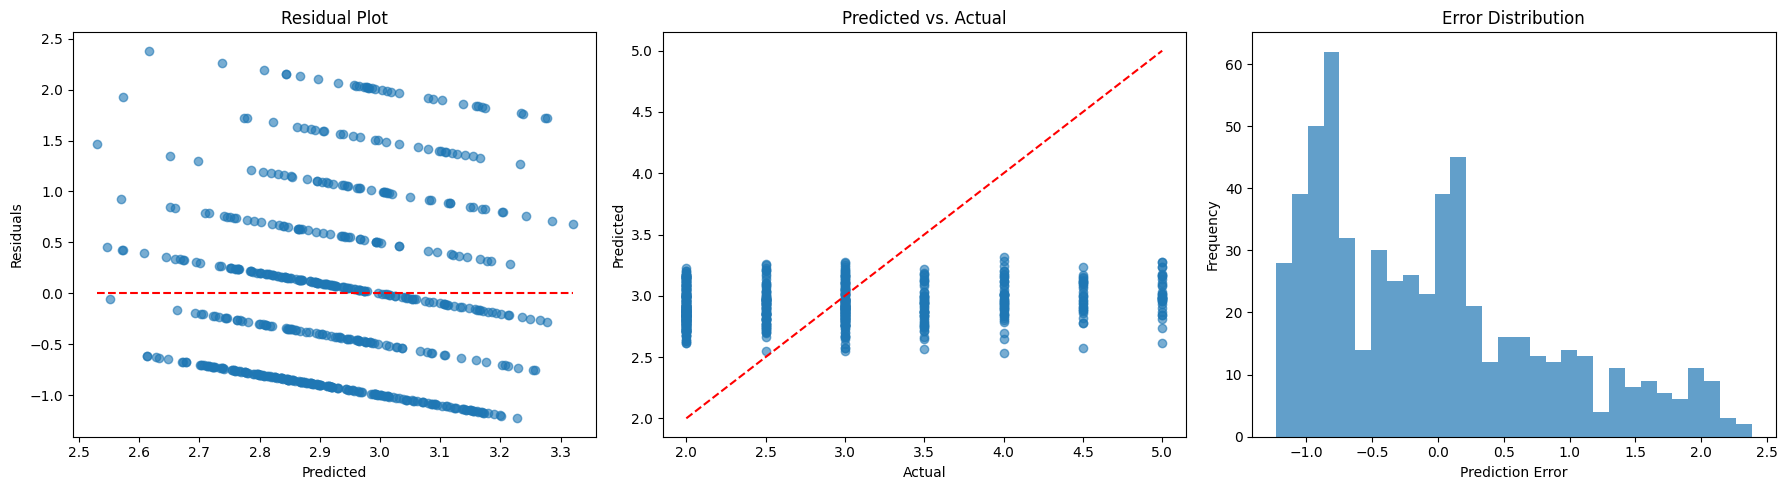

{'mae': 0.7252337706089019, 'mse': 0.7813732420304186, 'rmse': 0.8839531899543203, 'r2': 0.029949178626898387}


In [5]:
y_pred = best_model.predict(X_test)
emdedding_model_results = evaluate_regression_model(y_test, y_pred, show_plots=True)
print(emdedding_model_results)

In [6]:

# # Print model summary
best_model.summary()


Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 61)]              0         
_________________________________________________________________
dense (Dense)                (None, 192)               11904     
_________________________________________________________________
batch_normalization (BatchNo (None, 192)               768       
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 193       
Total params: 12,865
Trainable params: 12,481
Non-trainable params: 384
_________________________________________________________________


In [19]:
###extract embedings and saved them 

In [16]:
# Extract the last hidden layer (before the output)
embedding_layer = best_model.layers[-2].output  # -2 means second-to-last layer

# Create a new model that outputs the embeddings
embedding_model = Model(inputs=best_model.input, outputs=embedding_layer)

# Get embeddings for all users/items in the dataset
embeddings = embedding_model.predict(X_train)

# Convert embeddings to a DataFrame for better readability
embeddings_df = pd.DataFrame(embeddings)

# Show the first few embeddings
print(embeddings_df.head(2))
# Save as a CSV file
embeddings_df.to_csv("../data/embeddings.csv", index=False)

print("Embeddings saved successfully!")


        0         1         2         3       4         5         6    \
0 -0.098712  0.114449  1.140929 -0.568846  0.1149  0.114733 -0.550551   
1 -0.098712  0.114449 -0.953462  0.880489  0.1149  0.114733  0.902997   

        7         8         9    ...       182       183       184       185  \
0  1.325694  0.435046  0.980617  ...  1.085371 -0.123152  0.991851 -0.910416   
1 -0.674019  0.375592 -1.057817  ...  0.119638 -0.123152 -0.564354  0.776918   

       186       187       188       189       190       191  
0  0.11287 -0.248552 -1.080143 -0.634043  1.341483  1.096646  
1  0.11287  0.656166  0.807173  1.121526 -0.696733 -0.983000  

[2 rows x 192 columns]
Embeddings saved successfully!


In [ ]:
#retrieve embeding form the db

In [17]:
import pandas as pd

# Load the embeddings from the CSV file
embeddings_df = pd.read_csv("../data/embeddings.csv")

# Convert back to a NumPy array (if needed)
embeddings_train = embeddings_df.values

print("Embeddings loaded successfully!")
print("Embedding train shape")
print(embeddings_train.shape)  # Check the shape of the loaded embeddings
embeddings_test = embedding_model.predict(X_test)
print("Embedding test shape")
print(embeddings_test.shape) 


Embeddings loaded successfully!
Embedding train shape
(2400, 192)
Embedding test shape
(600, 192)


In [18]:
############  Create manual embeding for presentations

In [19]:
import pandas as pd
import numpy as np

# Step 1: Convert submission_date to datetime
presentations_df["submission_date"] = pd.to_datetime(presentations_df["submission_date"])

# Step 2: Compute recency in days
most_recent = presentations_df["submission_date"].max()
presentations_df["recency_days"] = (most_recent - presentations_df["submission_date"]).dt.days

# Step 3: Apply Step-Based Decay Function
def step_decay(days):
    if days <= 7:
        return 1.0           # last 7 days → highest weight
    elif days <= 30:
        return 0.85          # past month
    elif days <= 90:
        return 0.6           # past quarter
    elif days <= 180:
        return 0.4          # past half of year
    else:
        return 0.2          # older presentations

presentations_df["time_weight"] = presentations_df["recency_days"].apply(step_decay)

# Step 4: Define problem columns
problem_columns = [
    "Boring presentation", "Graphics", "Readability", "Consistency",
    "Images", "Bullets", "Text size", "Text heavy", "Tables",
    "Agenda", "Infographics", "Positioning"
]

# Step 5: Weight problem features by time_weight
weighted_problems = presentations_df[problem_columns].multiply(presentations_df["time_weight"], axis=0)
weighted_problems["user_id"] = presentations_df["user_id"]
weighted_problems["time_weight"] = presentations_df["time_weight"]

# Step 6: Aggregate to user-level by weighted average
presentations_embeddings = (
    weighted_problems
    .groupby("user_id")
    .apply(lambda g: g[problem_columns].sum() / g["time_weight"].sum())
    .reset_index()
)

# presentations_embeddings now contains 1 row per user with weighted average features
print(presentations_embeddings.shape)


(30, 13)


# make the both embeding same cardinality

In [23]:
def fix_presentation_embedding_cardinality_to_fit_interaction_data(interaction_df, embeddings_df, user_col="user_id", suffix="_pres"):
    """
    Fixes presentation embedding cardinality by expanding user-level embeddings to match 
    the interaction-level data using a merge on user_id.

    Parameters:
        interaction_df (pd.DataFrame): Interaction dataframe with user_id
        embeddings_df (pd.DataFrame): Presentation embedding dataframe with user_id and features
        user_col (str): Name of the user ID column (default is 'user_id')
        suffix (str): Suffix to append to embedding columns to avoid name clashes

    Returns:
        interaction_with_embeddings (pd.DataFrame): Interaction data with embeddings merged
        embedding_matrix (np.ndarray): Numpy array of expanded embeddings aligned with interaction_df
    """
    original_cols = set(interaction_df.columns)

    # Merge with suffix to avoid column name clashes
    interaction_with_embeddings = interaction_df.merge(
        embeddings_df,
        on=user_col,
        how="left",
        suffixes=('', suffix)
    )

    # Identify columns that came from the embeddings_df
    new_embed_cols = [col for col in interaction_with_embeddings.columns if col.endswith(suffix)]
    new_embed_cols.sort()

    # Extract matrix
    presentation_embedding = interaction_with_embeddings[new_embed_cols].values

    return  presentation_embedding

presentation_embedding_train = fix_presentation_embedding_cardinality_to_fit_interaction_data(interaction_train, presentations_embeddings )
presentation_embedding_test = fix_presentation_embedding_cardinality_to_fit_interaction_data(interaction_test, presentations_embeddings )

In [24]:
presentation_embedding_train.shape

(2400, 12)

In [ ]:
##########  RS MODEL ##################

<details>
  <summary><strong>GENERATE Model that uses embedings </strong></summary>

the model will use embedings created from user,article interaction as a first input and manual created embedding for presentations with time decay as a second input. The embedding are custome created. 

</details>


In [25]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
import kerastuner as kt

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Define model builder
def build_tuned_model(hp):
    use_batchnorm = hp.Boolean("use_batchnorm", default=False)
    use_dropout = hp.Boolean("use_dropout", default=False)
    dropout_rate = hp.Float("dropout_rate", 0.1, 0.5, step=0.1)
    l2_reg = hp.Float("l2_regularization", 1e-5, 1e-3, sampling="log")

    # Input 1
    input1 = Input(shape=(192,), name="embedding_256")
    x1 = input1
    for i in range(hp.Int("x1_layers", 1, 3)):
        x1 = Dense(
            units=hp.Int(f"x1_units_{i}", 32, 256, step=32),
            activation="relu",
            kernel_regularizer=l2(l2_reg)
        )(x1)
        if use_batchnorm:
            x1 = BatchNormalization()(x1)
        if use_dropout:
            x1 = Dropout(rate=dropout_rate)(x1)

    # Input 2
    input2 = Input(shape=(12,), name="embedding_13")
    x2 = input2
    for i in range(hp.Int("x2_layers", 1, 2)):
        x2 = Dense(
            units=hp.Int(f"x2_units_{i}", 16, 64, step=16),
            activation="relu",
            kernel_regularizer=l2(l2_reg)
        )(x2)
        if use_batchnorm:
            x2 = BatchNormalization()(x2)
        if use_dropout:
            x2 = Dropout(rate=dropout_rate)(x2)

    # Concatenate
    x = Concatenate()([x1, x2])
    for i in range(hp.Int("post_concat_layers", 1, 3)):
        x = Dense(
            units=hp.Int(f"concat_units_{i}", 32, 128, step=32),
            activation="relu",
            kernel_regularizer=l2(l2_reg)
        )(x)
        if use_batchnorm:
            x = BatchNormalization()(x)
        if use_dropout:
            x = Dropout(rate=dropout_rate)(x)

    output = Dense(1, activation="linear")(x)

    model = Model(inputs=[input1, input2], outputs=output)
    model.compile(
        optimizer=Adam(
            learning_rate=hp.Choice("learning_rate", [0.001, 0.0005, 0.0001])
        ),
        loss="mse",
        metrics=["mae"]
    )
    return model

# Define the tuner
tuner = kt.RandomSearch(
    build_tuned_model,
    objective="val_loss",
    max_trials=30,
    executions_per_trial=1,
    directory="my_tuner",
    project_name="rs_model_search",
    overwrite=True
)

# Show the search space summary
tuner.search_space_summary()

# Run the tuner search
tuner.search(
    [embeddings_train, presentation_embedding_train],
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=2
)

# Retrieve best model and hyperparameters
best_rs_model = tuner.get_best_models(num_models=1)[0]
best_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]

print("✅ Best hyperparameters:")
for param, value in best_hyperparameters.values.items():
    print(f"{param}: {value}")


Trial 30 Complete [00h 00m 19s]
val_loss: 0.5286940336227417

Best val_loss So Far: 0.41893842816352844
Total elapsed time: 00h 12m 04s
INFO:tensorflow:Oracle triggered exit
✅ Best hyperparameters:
use_batchnorm: False
use_dropout: False
dropout_rate: 0.5
l2_regularization: 1.6600002758463573e-05
x1_layers: 3
x1_units_0: 32
x2_layers: 1
x2_units_0: 48
post_concat_layers: 2
concat_units_0: 96
learning_rate: 0.0001
x1_units_1: 96
x2_units_1: 48
x1_units_2: 32
concat_units_1: 32


In [33]:
from sklearn.model_selection import KFold
import numpy as np
import time
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)


# Start timing
start_time = time.time()

# KFold setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)
history_list = []

# Perform CV
for fold, (train_idx, val_idx) in enumerate(kf.split(embeddings_train), start=1):
    print(f"\n--- Fold {fold} ---")

    embeddings_train_fold = embeddings_train[train_idx]
    presentation_embedding_train_fold = presentation_embedding_train[train_idx]
    train_labels_fold = y_train[train_idx]

    embeddings_val_fold = embeddings_train[val_idx]
    presentation_embedding_val_fold = presentation_embedding_train[val_idx]
    val_labels_fold = y_train[val_idx]
    model = tuner.hypermodel.build(best_hyperparameters)

    history = model.fit(
        [embeddings_train_fold, presentation_embedding_train_fold], 
        train_labels_fold,
        validation_data=(
            [embeddings_val_fold, presentation_embedding_val_fold], 
            val_labels_fold
        ),
        epochs=200,
        batch_size=32,
        callbacks=[early_stop],
        verbose=1
    )

    history_list.append(history)

# Metrics
avg_val_loss = np.mean([h.history['val_loss'][-1] for h in history_list])
avg_val_mae = np.mean([h.history['val_mae'][-1] for h in history_list])

print(f"\nAverage Validation Loss: {avg_val_loss:.4f}")
print(f"Average Validation MAE: {avg_val_mae:.4f}")
print(f"Total Execution Time: {time.time() - start_time:.2f} seconds")



--- Fold 1 ---
Epoch 1/200
60/60 [==============================] - 1s 9ms/step - loss: 5.3565 - mae: 2.0839 - val_loss: 2.8951 - val_mae: 1.3789
Epoch 2/200
60/60 [==============================] - 0s 4ms/step - loss: 1.7785 - mae: 1.0456 - val_loss: 1.2943 - val_mae: 0.9133
Epoch 3/200
60/60 [==============================] - 0s 4ms/step - loss: 1.1003 - mae: 0.8402 - val_loss: 1.0301 - val_mae: 0.8244
Epoch 4/200
60/60 [==============================] - 0s 4ms/step - loss: 0.9386 - mae: 0.7837 - val_loss: 0.9056 - val_mae: 0.7838
Epoch 5/200
60/60 [==============================] - 0s 4ms/step - loss: 0.8377 - mae: 0.7500 - val_loss: 0.8205 - val_mae: 0.7534
Epoch 6/200
60/60 [==============================] - 0s 4ms/step - loss: 0.7692 - mae: 0.7250 - val_loss: 0.7613 - val_mae: 0.7239
Epoch 7/200
60/60 [==============================] - 0s 4ms/step - loss: 0.7233 - mae: 0.7075 - val_loss: 0.7266 - val_mae: 0.7145
Epoch 8/200
60/60 [==============================] - 0s 4ms/step - 

In [78]:
# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import Input, Dense, Concatenate
# from tensorflow.keras.optimizers import Adam

# # Input 1: e.g. user/item embedding
# input1 = Input(shape=(32,), name="embedding_256")

# # Input 2: e.g. problem feature embedding
# input2 = Input(shape=(12,), name="embedding_13")

# # Optional: process each input separately (recommended for feature learning)
# x1 = Dense(128, activation="relu")(input1)
# x1 = Dense(64, activation="relu")(x1)

# x2 = Dense(32, activation="relu")(input2)
# x2 = Dense(16, activation="relu")(x2)

# # Combine both
# combined = Concatenate()([x1, x2])
# x = Dense(64, activation="relu")(combined)
# x = Dense(32, activation="relu")(x)
# output = Dense(1, activation="linear")(x)  # Or 'sigmoid' for binary

# # Build and compile
# model = Model(inputs=[input1, input2], outputs=output)
# model.compile(optimizer=Adam(learning_rate=0.001), loss="mse", metrics=["mae"])
# model.summary()


Model: "model_2"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
embedding_256 (InputLayer)      [(None, 32)]         0                                            
__________________________________________________________________________________________________
embedding_13 (InputLayer)       [(None, 12)]         0                                            
__________________________________________________________________________________________________
dense_4 (Dense)                 (None, 128)          4224        embedding_256[0][0]              
__________________________________________________________________________________________________
dense_6 (Dense)                 (None, 32)           416         embedding_13[0][0]               
____________________________________________________________________________________________

In [ ]:
#model test

✅ Mean Absolute Error (MAE): 0.5171
✅ Mean Squared Error (MSE): 0.4078
✅ Root Mean Squared Error (RMSE): 0.6386
✅ R² Score: 0.4937


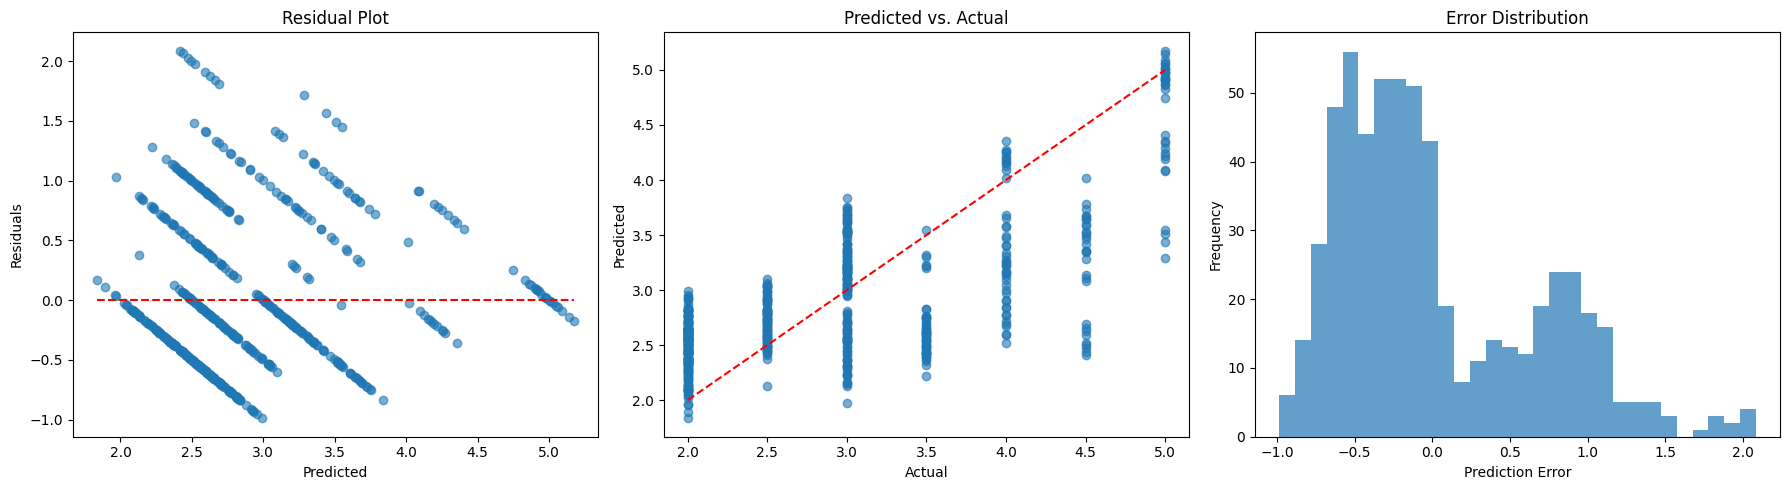

{'mae': 0.5170510127147039, 'mse': 0.4078154287369512, 'rmse': 0.6386042818028635, 'r2': 0.49370970192564834}


In [34]:
import numpy as np
y_pred = model.predict([embeddings_test, presentation_embedding_test])
recommendation_model_results = evaluate_regression_model(y_test, y_pred, show_plots=True)
print(recommendation_model_results)

# TODO Recommendation system usage

In [20]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

def prepare_presentation_sequences(presentation_df, max_sequence_length=None):
    """
    Prepare presentation data as sequences for each user.

    Parameters:
        presentation_df (pd.DataFrame): DataFrame with presentation features and submission dates.
        max_sequence_length (int): Maximum sequence length for padding or truncation.

    Returns:
        dict: Dictionary of padded sequences keyed by user_id.
    """
    # Sort by user_id and submission_date to ensure temporal order
    presentation_df = presentation_df.sort_values(by=['user_id', 'submission_date'])

    # Group by user_id and create sequences
    user_sequences = {}
    for user_id, group in presentation_df.groupby('user_id'):
        sequence = group.drop(columns=['user_id', 'presentation_id', 'submission_date']).values
        user_sequences[user_id] = sequence

    # Pad sequences to the same length
    all_sequences = list(user_sequences.values())
    padded_sequences = pad_sequences(all_sequences, maxlen=max_sequence_length, dtype='float32', padding='post', truncating='post')

    return {user_id: seq for user_id, seq in zip(user_sequences.keys(), padded_sequences)}


 # for the articles could be added popularity score

In [21]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam



# Data Preparation Function
def prepare_interaction_data(user_profile, recommendations, ratings_matrix, presentation_type_options, audience_type_options):
    """
    Prepare the interaction data for training.
    """
    interaction_data = pd.merge(ratings_matrix, user_profile, on='user_id', how='inner')
    recommendations_flat = flatten_recommendation_features(recommendations, presentation_type_options, audience_type_options)
    interaction_data = pd.merge(interaction_data, recommendations_flat, on='article_id', how='inner')

    feature_columns = [
        col for col in interaction_data.columns
        if col not in ['user_id', 'article_id', 'rating', 'location', 'Main issue', 'location_restrictions']
    ]
    X = interaction_data[feature_columns]
    y = interaction_data['rating']

    return interaction_data, X, y, feature_columns

# Utility to One-Hot Encode Features
def flatten_recommendation_features(recommendations, presentation_type_options, audience_type_options):
    """
    One-hot encode `presentation_type` and `audience_type` in recommendations.
    """
    presentation_columns = {ptype: f"presentation_type_{ptype}" for ptype in presentation_type_options}
    presentation_df = pd.DataFrame(0, index=recommendations.index, columns=presentation_columns.values())
    for i, ptypes in enumerate(recommendations['presentation_type']):
        for ptype in ptypes:
            if ptype in presentation_columns:
                presentation_df.loc[i, presentation_columns[ptype]] = 1

    audience_columns = {atype: f"audience_type_{atype}" for atype in audience_type_options}
    audience_df = pd.DataFrame(0, index=recommendations.index, columns=audience_columns.values())
    for i, atypes in enumerate(recommendations['audience_type']):
        for atype in atypes:
            if atype in audience_columns:
                audience_df.loc[i, audience_columns[atype]] = 1

    return pd.concat(
        [recommendations.drop(columns=['presentation_type', 'audience_type']), presentation_df, audience_df],
        axis=1
    )

import pandas as pd
import numpy as np

def generate_user_recommendations(model, user_profile, recommendations, feature_columns, ratings_matrix, presentation_sequences):
    """
    Generate user-specific recommendations based on the trained model and include true ratings.

    Parameters:
        model: Trained regression model.
        user_profile (pd.DataFrame): DataFrame containing user-specific preferences and attributes.
        recommendations (pd.DataFrame): DataFrame containing articles to recommend.
        feature_columns (list): List of feature columns used for prediction.
        ratings_matrix (pd.DataFrame): DataFrame containing user-item interactions with true ratings.
        presentation_sequences (dict): Dictionary with user_id as keys and corresponding presentation sequences as values.

    Returns:
        pd.DataFrame: DataFrame of personalized recommendations with true and predicted ratings.
    """
    # Ensure necessary columns exist
    if 'article_id' not in recommendations.columns or 'user_id' not in ratings_matrix.columns:
        raise KeyError("'article_id' or 'user_id' column is missing in the input DataFrames.")
    if 'article_id' not in recommendations.columns:
        raise KeyError("'article_id' column is missing in recommendations.")
    if 'article_id' not in ratings_matrix.columns:
        raise KeyError("'article_id' column is missing in ratings_matrix.")
        
    all_recommendations = []
    
    for user_id in user_profile['user_id'].unique():
        # Extract user's profile data
        user_data = user_profile[user_profile['user_id'] == user_id]
        
        # Prepare recommendations enriched with user profile features
        user_recommendations = recommendations.copy()
        for col in user_data.columns:
            if col not in ['user_id', 'location']:
                user_recommendations[col] = user_data[col].values[0]
        
        # Ensure all feature columns are present in user_recommendations
        for feature in feature_columns:
            if feature not in user_recommendations.columns:
                user_recommendations[feature] = 0


        # Select only the necessary feature columns for tabular data
        tabular_features = user_recommendations[feature_columns]
        tabular_features_array = tabular_features.to_numpy(dtype=np.float32)

        # Get the presentation sequence for the current user
        sequence_features = np.array(presentation_sequences.get(user_id, []), dtype=np.float32)

        # Ensure sequence_features is in the correct shape (e.g., [batch_size, sequence_length, feature_dim])
        sequence_features = np.expand_dims(sequence_features, axis=0)  # Adjust as needed to match expected input shape

        # Check for NaNs in the sequence features and handle them
        if np.isnan(sequence_features).any():
            sequence_features = np.nan_to_num(sequence_features)

        # Predict ratings using the trained model (both tabular and sequence inputs)
        user_recommendations['predicted_rating'] = model.predict([sequence_features, tabular_features_array])
        user_recommendations['user_id'] = user_id
        
        # Merge with true ratings
        user_ratings = ratings_matrix[ratings_matrix['user_id'] == user_id]
        user_recommendations = user_recommendations.merge(
            user_ratings[['article_id', 'rating']], 
            on='article_id', 
            how='left'
        ).rename(columns={'rating': 'true_rating'})
        
        all_recommendations.append(user_recommendations)
    
    # Concatenate all individual user recommendations into one DataFrame
    result = pd.concat(all_recommendations, ignore_index=True)
    return result


In [ ]:
###DATASET GENERATION
import pandas as pd
import numpy as np

recommendations_for_user_id=1
num_users = 20
num_articles = 50

# Generate articles dataset
recommendations = create_dataset(num_articles)

# Generate users:
user_profiles = generate_user_profiles(num_users, types, locations, preferences_options)

#Generate presentations
presentations_df = generate_presentations_for_users(num_users, presentation_problems)


In [22]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

def prepare_presentation_sequences(presentation_df, max_sequence_length=None):
    """
    Prepare presentation data as sequences for each user.

    Parameters:
        presentation_df (pd.DataFrame): DataFrame with presentation features and submission dates.
        max_sequence_length (int): Maximum sequence length for padding or truncation.

    Returns:
        dict: Dictionary of padded sequences keyed by user_id.
    """
    # Sort by user_id and submission_date to ensure temporal order
    presentation_df = presentation_df.sort_values(by=['user_id', 'submission_date'])

    # Group by user_id and create sequences
    user_sequences = {}
    for user_id, group in presentation_df.groupby('user_id'):
        sequence = group.drop(columns=['user_id', 'presentation_id', 'submission_date']).values
        user_sequences[user_id] = sequence

    # Pad sequences to the same length
    all_sequences = list(user_sequences.values())
    padded_sequences = pad_sequences(all_sequences, maxlen=max_sequence_length, dtype='float32', padding='post', truncating='post')

    return {user_id: seq for user_id, seq in zip(user_sequences.keys(), padded_sequences)}


In [23]:
def integrate_sequences_with_interaction_data(interaction_data, presentation_sequences):
    """
    Integrate user-specific presentation sequences into the interaction data.

    Parameters:
        interaction_data (pd.DataFrame): Interaction data containing user_id and other features.
        presentation_sequences (dict): Dictionary of presentation sequences keyed by user_id.

    Returns:
        tuple: Updated interaction data with sequences and the sequence array.
    """
    # Map sequences to interaction data
    interaction_data['presentation_sequence'] = interaction_data['user_id'].map(presentation_sequences)

    # Extract sequences for model input
    sequences = np.stack(interaction_data['presentation_sequence'].values)

    return interaction_data, sequences


In [27]:
###DATASET GENERATION
import pandas as pd
import numpy as np


#Generate rating matrix
ratings_matrix = None
ratings_matrix = generate_ratings_matrix(
    user_profiles, recommendations, presentations_df, ratings_matrix
)
#print("Rating matrix len: "+str(len(ratings_matrix)))

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Step 0: Preprocess the user profile
user_profiles_flat = preprocess_user_profile(user_profiles, preferences_options, types, presentation_type_options)

# Step 2: Prepare interaction data
interaction_data, X, y, feature_columns = prepare_interaction_data(user_profiles_flat, recommendations, ratings_matrix,presentation_type_options,audience_type_options)


# Prepare sequences from presentation_df
presentation_sequences = prepare_presentation_sequences(presentations_df, max_sequence_length=10)  # Example max length

# Integrate sequences with interaction data
interaction_data, presentation_input = integrate_sequences_with_interaction_data(interaction_data, presentation_sequences)

import numpy as np

# Convert to NumPy array and ensure correct dtype
presentation_input = np.array(presentation_input, dtype=np.float32)

# Check for NaNs
if np.isnan(presentation_input).any():
    print("Found NaNs in presentation_input. Filling with 0.")
    presentation_input = np.nan_to_num(presentation_input)

# Extract other features (X) and target (y)
X = interaction_data.drop(columns=['user_id', 'article_id', 'rating', 'presentation_sequence', 'location', 'location_restrictions', 'Main issue'])
y = interaction_data['rating']

print(type(y))
# Function to check if all columns contain only 0 or 1
def check_binary_columns(dataframe):
    non_binary_columns = []
    for column in dataframe.columns:
        if not dataframe[column].isin([0, 1]).all():
            non_binary_columns.append(column)
    
    if non_binary_columns:
        print(f"Columns with values other than 0 or 1 detected: {non_binary_columns}")
    else:
        print("All columns contain only 0 or 1.")

# Check your DataFrame
check_binary_columns(X)

X = X.to_numpy(dtype=np.float32)

if np.isnan(X).any():
    print("Found NaNs in X. Filling with 0.")
    X = np.nan_to_num(X)


C:\Users\maria\AppData\Local\Temp\ipykernel_8160\4131520157.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_presentations["recency_weight"] = (


<class 'pandas.core.series.Series'>
All columns contain only 0 or 1.


In [28]:
from sklearn.model_selection import train_test_split

# 1) First split: Train (70%) vs Temp (30%)
X_train, X_temp, y_train, y_temp, p_train, p_temp = train_test_split(
    X, 
    y, 
    presentation_input, 
    test_size=0.3, 
    random_state=42
)

# 2) Second split: Validation (15%) vs Test (15%)
X_val, X_test, y_val, y_test, p_val, p_test = train_test_split(
    X_temp, 
    y_temp, 
    p_temp, 
    test_size=0.5, 
    random_state=42
)

print("Shapes after splitting:")
print("  Train:", X_train.shape, y_train.shape, p_train.shape)
print("  Val:  ", X_val.shape,   y_val.shape,   p_val.shape)
print("  Test: ", X_test.shape,  y_test.shape,  p_test.shape)


Shapes after splitting:
  Train: (2100, 59) (2100,) (2100, 10, 12)
  Val:   (450, 59) (450,) (450, 10, 12)
  Test:  (450, 59) (450,) (450, 10, 12)


In [29]:
!pip install keras-tuner

In [34]:
import numpy as np
import tensorflow as tf
import kerastuner as kt  # or `import keras_tuner as kt`
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, Concatenate, BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


def build_model(hp):
    """
    Build a multi-input Keras model that:
    1) Processes sequence data (presentation_input) with an LSTM branch.
    2) Processes other features (other_features_input) with a Dense branch.
    3) Concatenates them and outputs a single value (regression).
    """
    # --- Hyperparameters to tune ---
    lstm_units = hp.Choice('lstm_units', [32, 64, 128])
    lstm_dropout = hp.Float('lstm_dropout', 0.0, 0.5, step=0.1)
    dense_units = hp.Choice('dense_units', [16, 32, 64])
    dense_dropout = hp.Float('dense_dropout', 0.0, 0.5, step=0.1)
    combined_dense_units = hp.Choice('combined_dense_units', [16, 32, 64])
    learning_rate = hp.Choice('learning_rate', [1e-3, 5e-4, 1e-4])

    # --- RNN Branch ---
    sequence_input = Input(shape=(10, 12), name="presentation_input")  # (time_steps=10, features=12)
    p = LSTM(lstm_units, return_sequences=False, name="lstm_layer")(sequence_input)
    p = Dropout(lstm_dropout, name="dropout_rnn")(p)

    # Optional batch normalization
    # p = BatchNormalization()(p)

    # --- Dense Branch ---
    other_features_input = Input(shape=(59,), name="other_features_input")
    o = Dense(dense_units, activation='relu', name="dense_other")(other_features_input)
    o = Dropout(dense_dropout, name="dropout_other")(o)
    # o = BatchNormalization()(o)

    # --- Concatenate the two branches ---
    combined = Concatenate(name="concat_layer")([p, o])

    # --- Combined Dense Layer(s) ---
    z = Dense(combined_dense_units, activation='relu', name="dense_combined")(combined)
    # You could add another layer if you like:
    # z = Dense(hp.Choice('combined_dense_units_2', [16, 32]), activation='relu')(z)

    # --- Output Layer ---
    output = Dense(1, activation='linear', name="output")(z)

    # Build and compile the model
    model = Model(inputs=[sequence_input, other_features_input], outputs=output)
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mean_squared_error',
        metrics=['mae', 'mse', tf.keras.metrics.RootMeanSquaredError()]
    )

    return model

tuner = kt.RandomSearch(
    hypermodel=build_model,
    objective='val_loss',        # We want to minimize val_loss
    max_trials=5,                # How many hyperparameter combinations to try
    executions_per_trial=1,      # How many times to train each combination
    overwrite=True,              # Overwrite previous results in the same directory
    directory='my_tuner_dir',    # Directory to store logs
    project_name='multi_input_project'
)

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

#tuner.search(
#    x=[p_train, X_train],
#    y=y_train,
#    validation_data=([p_val, X_val], y_val),
#    epochs=50,           # Max epochs per trial
#    batch_size=16,
#    callbacks=[early_stopping]
#)
tuner.search(
    x=[p_train, X_train],
    y=y_train.to_numpy(),
    validation_data=([p_val, X_val], y_val.to_numpy()),
    epochs=50,           # Max epochs per trial
    batch_size=16,
    callbacks=[early_stopping]
)


best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters found:")
for param_name, param_value in best_hps.values.items():
    print(f"  {param_name}: {param_value}") 

### get the best model # Get the best model from the search
best_model = tuner.get_best_models(num_models=1)[0]

best_model.summary()

## Retrain the best model for more epochs
# Retrain the best model for more epochs
best_model.fit(
    [X_user_train, X_item_train, X_time_train],  # Training data
    y_train,  # Target labels
    epochs=50,  # Retrain for 50 more epochs (or as many as you need)
    validation_data=([X_user_test, X_item_test, X_time_test], y_test),  # Validation data
    batch_size=32  # Batch size
)

# Save the best model
best_model.save("best_retrained_model.h5")

y_pred = best_model.predict([X_user_test, X_item_test, X_time_test])

Trial 5 Complete [00h 00m 16s]
val_loss: 0.3226286768913269

Best val_loss So Far: 0.31693458557128906
Total elapsed time: 00h 01m 54s
INFO:tensorflow:Oracle triggered exit
Best hyperparameters found:
  lstm_units: 64
  lstm_dropout: 0.2
  dense_units: 64
  dense_dropout: 0.1
  combined_dense_units: 32
  learning_rate: 0.0001
Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
presentation_input (InputLayer) [(None, 10, 12)]     0                                            
__________________________________________________________________________________________________
other_features_input (InputLaye [(None, 59)]         0                                            
__________________________________________________________________________________________________
lstm_layer (LSTM)               (None, 64)           19712     

NameError: name 'X_user_train' is not defined

In [31]:
# #Tuned version

# import numpy as np
# import tensorflow as tf
# import keras_tuner as kt
# from tensorflow.keras.layers import (
#     Input, LSTM, Dense, Dropout, Concatenate, BatchNormalization, Bidirectional
# )
# from tensorflow.keras.models import Model
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# def build_model(hp):
#     """
#     Build a multi-input Keras model that:
#     1) Processes sequence data (presentation_input) with an LSTM branch.
#     2) Processes other features (other_features_input) with a Dense branch.
#     3) Concatenates them and outputs a single value (regression).
#     """
#     # --- Hyperparameters to tune ---
#     lstm_units = hp.Choice('lstm_units', [32, 64, 128, 256])
#     lstm_dropout = hp.Float('lstm_dropout', 0.0, 0.6, step=0.1)
#     dense_units = hp.Choice('dense_units', [16, 32, 64, 128])
#     dense_dropout = hp.Float('dense_dropout', 0.0, 0.6, step=0.1)
#     combined_dense_units = hp.Choice('combined_dense_units', [16, 32, 64, 128])
#     learning_rate = hp.Choice('learning_rate', [1e-3, 5e-4, 1e-4, 5e-5])

#     # --- RNN Branch ---
#     sequence_input = Input(shape=(10, 12), name="presentation_input")  # (time_steps=10, features=12)
#     p = Bidirectional(LSTM(lstm_units, return_sequences=False, name="lstm_layer"))(sequence_input)
#     p = Dropout(lstm_dropout, name="dropout_rnn")(p)
#     p = BatchNormalization()(p)

#     # --- Dense Branch ---
#     other_features_input = Input(shape=(59,), name="other_features_input")
#     o = Dense(dense_units, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4), name="dense_other")(other_features_input)
#     o = Dropout(dense_dropout, name="dropout_other")(o)
#     o = BatchNormalization()(o)

#     # --- Concatenate the two branches ---
#     combined = Concatenate(name="concat_layer")([p, o])

#     # --- Combined Dense Layer(s) ---
#     z = Dense(combined_dense_units, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4), name="dense_combined")(combined)
#     z = BatchNormalization()(z)
#     z = Dense(hp.Choice('combined_dense_units_2', [16, 32, 64, 128]), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4), name="dense_combined_2")(z)
#     z = Dropout(0.3)(z)

#     # --- Output Layer ---
#     output = Dense(1, activation='linear', name="output")(z)

#     # Build and compile the model
#     model = Model(inputs=[sequence_input, other_features_input], outputs=output)
#     model.compile(
#         optimizer=Adam(learning_rate=learning_rate),
#         loss='mean_squared_error',
#         metrics=['mae', tf.keras.metrics.RootMeanSquaredError()]
#     )

#     return model


# # --- Keras Tuner ---
# tuner = kt.RandomSearch(
#     hypermodel=build_model,
#     objective='val_loss',
#     max_trials=20,  # Increased number of trials for better search
#     executions_per_trial=1,
#     overwrite=True,
#     directory='my_tuner_dir',
#     project_name='multi_input_project'
# )

# # --- Callbacks ---
# early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
# lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

# # --- Hyperparameter Search ---
# tuner.search(
#     x=[p_train, X_train],
#     y=y_train,
#     validation_data=([p_val, X_val], y_val),
#     epochs=50,  # Increased epochs
#     batch_size=16,  # Increased batch size
#     callbacks=[early_stopping, lr_scheduler]
# )

# # --- Best Hyperparameters ---
# best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
# print("Best hyperparameters found:")
# for param_name, param_value in best_hps.values.items():
#     print(f"  {param_name}: {param_value}")


In [ ]:

import time
best_model = tuner.hypermodel.build(best_hps)

y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# Timing the training process
start_time = time.time()
# Retrain it (often with more epochs):
history = best_model.fit(
    x=[p_train, X_train],
    y=y_train.to_numpy(),
    epochs=50,
    validation_data=([p_val, X_val], y_val.to_numpy()),
    batch_size=16,
    callbacks=[early_stopping]
)

end_time = time.time()

# Calculate the elapsed time
elapsed_time = end_time - start_time
print(f"Total training time: {elapsed_time:.2f} seconds")
test_loss, test_mae, test_mse, test_rmse = best_model.evaluate([p_test, X_test], y_test)
print("Test Loss:", test_loss)
print("Test MAE:", test_mae)
print("Test MSE:", test_mse)
print("Test RMSE:", test_mae)

In [ ]:
"""
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Concatenate
from tensorflow.keras.models import Model

# RNN branch
sequence_input = Input(shape=(10, 12), name="presentation_input")  # time_steps=10, features=12
p = LSTM(32, return_sequences=False, name="lstm_layer")(sequence_input)
p = Dropout(0.2, name="dropout_rnn")(p)

other_features_input = Input(shape=(59,), name="other_features_input")  
o = Dense(32, activation='relu', name="dense_other")(other_features_input)
o = Dropout(0.2, name="dropout_other")(o)

combined = Concatenate(name="concat_layer")([p, o])
z = Dense(16, activation='relu', name="dense_combined")(combined)
output = Dense(1, activation='linear', name="output")(z)

model = Model(inputs=[sequence_input, other_features_input], outputs=output)
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.fit(
    x=[p_train, X_train],
    y=y_train,
    epochs=50,
    batch_size=16,
    validation_data=([p_val, X_val], y_val),
    callbacks=[early_stopping]
)
"""



In [ ]:
"""
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, Concatenate, BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# 1) Define RNN branch for presentation data
sequence_input = Input(shape=(10, 12), name="presentation_input")  # (time_steps=10, features=12)

# Stacked LSTM layers
p = LSTM(64, return_sequences=True, name="lstm_layer1")(sequence_input)
p = Dropout(0.2, name="dropout_lstm1")(p)

p = LSTM(32, return_sequences=False, name="lstm_layer2")(p)
p = Dropout(0.2, name="dropout_lstm2")(p)

# Optional batch normalization
p = BatchNormalization(name="batchnorm_rnn")(p)

# 2) Define Dense branch for other features
other_features_input = Input(shape=(59,), name="other_features_input")

# Multiple Dense layers
o = Dense(64, activation='relu', name="dense_other_1")(other_features_input)
o = Dropout(0.3, name="dropout_other_1")(o)

o = Dense(32, activation='relu', name="dense_other_2")(o)
o = Dropout(0.2, name="dropout_other_2")(o)

o = BatchNormalization(name="batchnorm_other")(o)

# 3) Concatenate both branches
combined = Concatenate(name="concat_layer")([p, o])

# 4) Further dense layers on top
z = Dense(32, activation='relu', name="dense_combined_1")(combined)
z = Dropout(0.2, name="dropout_combined_1")(z)

z = Dense(16, activation='relu', name="dense_combined_2")(z)

# 5) Final output
output = Dense(1, activation='linear', name="output")(z)

# 6) Build and compile model
model = Model(inputs=[sequence_input, other_features_input], outputs=output)
model.compile(optimizer=Adam(learning_rate=1e-3), loss='mean_squared_error', metrics=['mae'])

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.fit(
    x=[p_train, X_train],
    y=y_train,
    epochs=50,
    batch_size=16,
    validation_data=([p_val, X_val], y_val),
    callbacks=[early_stopping]
)
"""


In [ ]:
"""
# 2) Evaluate the model on the test set
test_loss, test_mae = model.evaluate(
    [p_test, X_test],  # two-input test data
    y_test,            # test target
    batch_size=32
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test MAE:  {test_mae:.4f}")
"""

In [ ]:
########### ITERATIVE TRAINING

In [ ]:
def incremental_train_model(
    model,
    old_interaction_data,
    old_presentation_sequences,
    new_user_profile,
    new_recommendations,
    new_ratings_matrix,
    presentation_type_options,
    audience_type_options,
    epochs=5,
    batch_size=16
):
    """
    Continues training the existing Keras model with new user/item interactions.
    Merges new data with a subset of old data to avoid catastrophic forgetting.
    """

    # 1. Merge new data into your training set
    # Prepare interaction data from new user profiles & new recommendations
    # Using the same pipeline you had before:
    new_interaction_data, X_new, y_new, feature_columns_new = prepare_interaction_data(
        new_user_profile,
        new_recommendations,
        new_ratings_matrix,
        presentation_type_options,
        audience_type_options
    )

    # 2. Optionally, sample some old data for "memory replay"
    #    This prevents the model from forgetting old patterns
    old_sample = interaction_data.sample(frac=0.1, random_state=42)  # e.g., 10% old data
    # Build partial old X/y from old_sample
    feature_columns_old = [col for col in old_sample.columns if col not in ['user_id', 'article_id', 'rating']]
    X_old = old_sample[feature_columns_old].to_numpy(dtype='float32')
    y_old = old_sample['rating'].to_numpy(dtype='float32')

    # 3. Combine the new and old data
    X_combined = np.concatenate([X_new.to_numpy(dtype='float32'), X_old], axis=0)
    y_combined = np.concatenate([y_new.to_numpy(dtype='float32'), y_old], axis=0)

    # 4. Combine or replicate presentation sequences
    #    - new_presentation_sequences for new interactions
    #    - old_presentation_sequences subset for old data
    # Build these similarly to your main training pipeline

    # Example: Suppose new_interaction_data has shape (N_new,) and old_sample has shape (N_old,)
    # Build p_combined by repeating/stacking sequences accordingly
    # [This part depends heavily on how your sequences are stored and matched to rows!]
    p_new = []
    for idx, row in new_interaction_data.iterrows():
        uid = row['user_id']
        seq = presentation_sequences.get(uid, np.zeros((10,1)))  # fallback or handle
        p_new.append(seq)
    p_new = np.array(p_new, dtype='float32')

    p_old = []
    for idx, row in old_sample.iterrows():
        uid = row['user_id']
        seq = opresentation_sequences.get(uid, np.zeros((10,1)))  # fallback or handle
        p_old.append(seq)
    p_old = np.array(p_old, dtype='float32')

    # Concatenate new + old
    p_combined = np.concatenate([p_new, p_old], axis=0)

    # 5. Continue training from current weights
    model.fit(
        [p_combined, X_combined],
        y_combined,
        epochs=epochs,
        batch_size=batch_size,
        verbose=1
    )

    return model  # The model is now updated


In [ ]:
# Example usage:
best_model = incremental_train_model(
    model=best_model,
    old_interaction_data=interaction_data,  # from your original training
    old_presentation_sequences=p_train_dict, # your original train user->sequence mapping
    new_user_profile=new_user_profiles,
    new_recommendations=new_recommendations_df,
    new_ratings_matrix=new_ratings_df,
    presentation_type_options,
    audience_type_options,
    epochs=5,
    batch_size=16
)
updated_recommendations = generate_user_recommendations(
    model=best_model,
    user_profile=user_profiles_flat,           # can include new + old
    recommendations=recommendations,           # can include new + old
    feature_columns=feature_columns,
    ratings_matrix=ratings_matrix,             # can include new + old
    presentation_sequences=p_train_dict        # updated with new sequences if necessary
)


In [ ]:
###DATASET GENERATION
""""
import pandas as pd
import numpy as np

recommendations_for_user_id=1
num_users = 50
num_articles = 500

# Generate articles dataset
recommendations = create_dataset(num_articles)

# Generate users:
user_profiles = generate_user_profiles(num_users, types, locations, preferences_options)

#Generate presentations
presentations_df = generate_presentations_for_users(num_users, presentation_problems)
#Generate rating matrix
ratings_matrix = None
ratings_matrix = generate_ratings_matrix(
    user_profiles, recommendations, presentations_df, ratings_matrix
)
#print("Rating matrix len: "+str(len(ratings_matrix)))

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Step 0: Preprocess the user profile
user_profiles_flat = preprocess_user_profile(user_profiles, preferences_options, types, presentation_type_options)

# Step 2: Prepare interaction data
interaction_data, X, y, feature_columns = prepare_interaction_data(user_profiles_flat, recommendations, ratings_matrix,presentation_type_options,audience_type_options)
""""

**Utility function**

In [ ]:
import pandas as pd

# Core utility calculation function
def calc_utility(row, presentation_issues, user_profile):
    """
    Calculate the utility score for a single row.

    Parameters:
        row (pd.Series): A row containing features and scores.
        presentation_issues (dict): A dictionary mapping features to issue values.
        user_profile (dict): User preferences and profile information.

    Returns:
        float: The calculated utility score.
    """
    utility_score = row.get('combined_score', 0)
    features = row.get('features', {})

    # Add feature-based utility
    for feature, value in features.items():
        if feature in user_profile.get('preferences', []):
            utility_score += value
        issue_value = presentation_issues.get(feature, 0)
        utility_score += issue_value * value

    return utility_score

def rearrange_recommendations_by_presentation_type(recommendations,user_profile):
    """
    Rearrange recommendations based on the user's preferred presentation type.
    """

    preferred_type = user_profile.get('preferred_presentation_type')

    # Rearrange recommendations with preferred type at the top
    recommendations['is_preferred'] = recommendations['presentation_type'] == preferred_type
    sorted_recommendations = recommendations.sort_values(by='is_preferred', ascending=False).drop(columns='is_preferred')

    return sorted_recommendations

# Adjust recommendations by user engagement time
def adjust_recommendations_by_engagement(recommendations, user_engagement_time):
    """
    Limit recommendations based on the user's engagement time.
    """
    max_recommendations = int(user_engagement_time / 5)  # 5 minutes = 1 recommendation
    return recommendations.head(max_recommendations)

# Apply location restrictions
def apply_location_restrictions(recommendations, user_location):
    """
    Filter recommendations based on location restrictions.
    """
    return recommendations[~recommendations['location_restrictions'].str.contains(user_location, na=False)]

# Enhanced utility calculation with audience matching
def calculate_utility_with_audience(row, presentation_issues, user_profile):
    """
    Calculate utility with additional audience type matching.
    """
    utility_score = calc_utility(row, presentation_issues, user_profile)
    if row.get('audience_type') == user_profile.get('audience_type'):
        utility_score *= 1.1  # Boost score for audience match
    return utility_score

# Enhanced utility function
def enhanced_utility_function(recommendations, presentation_issues, user_profile, engagement_data, location_data):
    """
    Apply filters, adjustments, and utility calculation with audience matching.
    """
    rec = rearrange_recommendations_by_presentation_type(recommendations, user_profile)
    #print(len(rec))
    rec = apply_location_restrictions(rec, location_data)
    #print(len(rec))
    rec['utility_score'] = rec.apply(
        lambda row: calculate_utility_with_audience(row, presentation_issues, user_profile), axis=1
    )
    rec = rec.sort_values('utility_score', ascending=False)
    # Remove duplicates based on 'article_id', keeping the first occurrence
    rec = rec.drop_duplicates(subset='article_id', keep='first')
    #print(len(rec))
    return rec


# Recommendation system data



In [ ]:
hybrid_recommendations = generate_user_recommendations(best_model, user_profiles_flat, recommendations, feature_columns, ratings_matrix, presentation_sequences)
print(hybrid_recommendations.columns)

In [ ]:
# Generate user-specific recommendations
#hybrid_recommendations = generate_user_recommendations(best_model, user_profiles_flat, recommendations, feature_columns, ratings_matrix)
#print(hybrid_recommendations.columns)

engagement_data = 15  # User engagement time in minutes
location_data = 'North America'

# Generate random binary values (0 or 1) for each problem
np.random.seed(42)  # For reproducibility
binary_values = np.random.choice([0, 1], len(presentation_problems))

# Create the presentation_issues as a Pandas Series
presentation_issues = pd.Series(data=binary_values, index=presentation_problems)
user_profile = user_profiles[user_profiles['user_id'] == recommendations_for_user_id].iloc[0].copy()
end_result=enhanced_utility_function(hybrid_recommendations, presentation_issues, user_profile, engagement_data, location_data)

# # Evaluate the model
# rmse = mean_squared_error(hybrid_recommendations['true_rating'], hybrid_recommendations['predicted_rating'])

# print(f"Test Set RMSE: {rmse:.2f}")

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Compute RMSE
rmse = mean_squared_error(hybrid_recommendations['true_rating'], hybrid_recommendations['predicted_rating'], squared=False)

# Compute MAEb
mae = mean_absolute_error(hybrid_recommendations['true_rating'], hybrid_recommendations['predicted_rating'])

# Print the results
print(f"Test Set RMSE: {rmse:.2f}")
print(f"Test Set MAE: {mae:.2f}")

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Compute RMSE
rmse = mean_squared_error(end_result['true_rating'], end_result['predicted_rating'], squared=False)

# Compute MAE
mae = mean_absolute_error(end_result['true_rating'], end_result['predicted_rating'])

# Print the results
print(f"Test Set RMSE: {rmse:.2f}")
print(f"Test Set MAE: {mae:.2f}")


In [ ]:
!pip install keras-tuner


In [ ]:
hybrid_recommendations.head(1)

# validation

Precision= Total recommendations/Number of relevant recommendations


In [ ]:
import pandas as pd

def calculate_precision(df, true_rating_col, predicted_rating_col, relevance_threshold):
    """
    Calculate precision based on the formula:
    Precision = Total Recommendations / Number of Relevant Recommendations.

    Parameters:
        df (pd.DataFrame): The dataset containing true and predicted ratings.
        true_rating_col (str): Column name for true ratings.
        predicted_rating_col (str): Column name for predicted ratings.
        relevance_threshold (float): threshold to determine relevance.

    Returns:
        float: Precision value.
    """

    # Determine relevant items based on true ratings
    df['is_relevant'] = df[true_rating_col] >= relevance_threshold

    # Determine predicted relevant items based on predicted ratings
    df['predicted_relevant'] = df[predicted_rating_col] >= relevance_threshold

    # Calculate Total Recommendations (predicted relevant items)
    total_recommendations = df['predicted_relevant'].sum()

    # Calculate Number of Relevant Recommendations (actual relevant items)
    number_of_relevant_recommendations = df['is_relevant'].sum()

    # Calculate Precision
    precision = (total_recommendations / number_of_relevant_recommendations
                 if number_of_relevant_recommendations > 0 else 0)

    return precision

# Calculate precision
# Define relevance threshold: Top 20% threshold
relevance_threshold = ratings_matrix['rating'].quantile(0.80)
precision = calculate_precision(end_result,'true_rating', 'predicted_rating',relevance_threshold)
print(f"Precision: {precision}")


Novelty measures how surprising or unexpected a recommendation is to the user. It’s often calculated using item popularity (less popular = more novel).

Steps:

Assign a popularity score to each item (e.g., based on how often it appears in the dataset).
Compute the novelty as the inverse popularity for each recommendation and average across recommendations.

In [ ]:
import pandas as pd

def calculate_novelty_by_inverse_popularity(df, item_col):
    """
    Calculate novelty as the average inverse of item popularity.

    Parameters:
        df (pd.DataFrame): Dataset containing items for which novelty is to be calculated.
        item_col (str): Column name for the item IDs (e.g., 'article_id').

    Returns:
        float: Average novelty score.
    """
    # Calculate item popularity
    item_popularity = df[item_col].value_counts()

    # Assign novelty as the inverse of popularity
    df['novelty'] = 1 / df[item_col].map(item_popularity)

    # Calculate average novelty
    novelty_score = df['novelty'].mean()

    return novelty_score

novelty_score = calculate_novelty_by_inverse_popularity(end_result, item_col='article_id')
print(f"Novelty Score: {novelty_score}")

Diversity measures how different the recommended items are from each other. It’s typically calculated using pairwise similarity between items in the recommendations.

Steps:

Calculate pairwise similarity for the features column.
Compute the average dissimilarity (1 - similarity) for all pairs of recommendations.

In [ ]:
# Filter the DataFrame to include 'article_id' and all columns in preferences_options
filtered_df = hybrid_recommendations[['article_id'] + preferences_options]

# Set 'article_id' as the index
features = filtered_df.set_index('article_id')

diversity_score = calculate_diversity(end_result, item_col='article_id', feature_matrix=features)
print(f"Diversity Score: {diversity_score}")


In [ ]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def calculate_diversity(df, item_col, feature_matrix):
    """
    Calculate diversity of recommendations as the average pairwise dissimilarity.

    Parameters:
        df (pd.DataFrame): Dataset containing recommended items.
        item_col (str): Column name for the item IDs (e.g., 'article_id').
        feature_matrix (pd.DataFrame or np.ndarray): Feature matrix of items (rows: items, cols: features).

    Returns:
        float: Diversity score (higher means more diverse recommendations).
    """
    # Extract recommended items
    recommended_items = df[item_col].unique()

    # Subset feature matrix for recommended items
    feature_subset = feature_matrix.loc[recommended_items]

    # Calculate pairwise cosine similarity
    similarity_matrix = cosine_similarity(feature_subset)

    # Convert similarity to dissimilarity (1 - similarity)
    dissimilarity_matrix = 1 - similarity_matrix

    # Calculate average pairwise dissimilarity
    num_items = len(recommended_items)
    if num_items < 2:
        return 0  # No diversity if fewer than 2 items are recommended

    # Take the upper triangle of the matrix (excluding diagonal)
    dissimilarity_values = dissimilarity_matrix[np.triu_indices(num_items, k=1)]
    diversity_score = dissimilarity_values.mean()

    return diversity_score


Types of Coverage:
User Coverage:

The percentage of users for whom the system can provide recommendations.
If coverage = 1, it means the system has made recommendations for 100% of the users.
Formula:

User Coverage
=
Users with Recommendations
Total Users
User Coverage=
Total Users
Users with Recommendations
​

Item Coverage:

The percentage of items that appear in at least one recommendation list.
If coverage = 1, it means every item in the catalog has been recommended at least once.
Formula:

Item Coverage
=
Items in Recommendations
Total Items
Item Coverage=
Total Items
Items in Recommendations
​

Example Interpretation:
User Coverage = 1:
The system is able to generate recommendations for all users in the dataset.
Item Coverage = 1:
The system has recommended all items from the catalog to at least one user.
Why Is Coverage Important?
Coverage is critical in recommendation systems for the following reasons:

Inclusivity: Ensures that all users or items are considered, preventing bias.
Diversity: Higher item coverage generally correlates with more diverse recommendations.


In [ ]:
import pandas as pd

def calculate_coverage(recommendations, user_col, item_col, total_users, total_items):
    """
    Calculate user and item coverage for a recommendation system.

    Parameters:
        recommendations (pd.DataFrame): DataFrame containing recommendations.
                                        Must include user and item columns.
        user_col (str): Column name for user IDs in the recommendations DataFrame.
        item_col (str): Column name for item IDs in the recommendations DataFrame.
        total_users (int): Total number of users in the dataset.
        total_items (int): Total number of items in the catalog.

    Returns:
        dict: A dictionary containing user coverage and item coverage.
    """
    # Users with recommendations
    users_with_recommendations = recommendations[user_col].nunique()

    # Items in recommendations
    items_in_recommendations = recommendations[item_col].nunique()

    # Calculate user coverage
    user_coverage = users_with_recommendations / total_users

    # Calculate item coverage
    item_coverage = items_in_recommendations / total_items

    return {
        'user_coverage': user_coverage,
        'item_coverage': item_coverage
    }


In [ ]:
# Example recommendation DataFrame
recommendations = end_result.copy()

# Total users and items in the dataset
total_users = 30  # Example: 6 users in the dataset
total_items = 300  # Example: 10 items in the catalog

# Calculate coverage
coverage = calculate_coverage(
    recommendations,
    user_col='user_id',
    item_col='article_id',
    total_users=total_users,
    total_items=total_items
)

print(f"User Coverage: {coverage['user_coverage']}")
print(f"Item Coverage: {coverage['item_coverage']}")
